In [1]:
import nibabel as nib
import matplotlib.pyplot as plt

In [2]:
img = nib.load("../data/BraTS/BraTS20_Training_001/BraTS20_Training_001_flair.nii")
data = img.get_fdata()

print(data.shape)

(240, 240, 155)


(np.float64(-0.5), np.float64(239.5), np.float64(239.5), np.float64(-0.5))

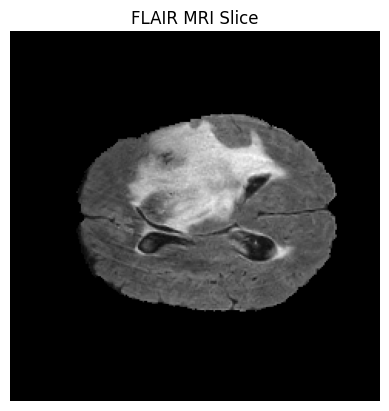

In [3]:
slice_index = 80

plt.imshow(data[:,:, slice_index], cmap = "gray")
plt.title("FLAIR MRI Slice")
plt.axis("off")

In [4]:
print(img.header.get_zooms()) # meaning 1mm voxel spacing

(np.float32(1.0), np.float32(1.0), np.float32(1.0))


First Preprocessing Experiment

TorchIO preprocssing

In [10]:
import torchio as tio

In [13]:
subject = tio.Subject(
    flair = tio.ScalarImage("../data/BraTS/BraTS20_Training_001/BraTS20_Training_001_flair.nii"),
    label = tio.LabelMap("../data/BraTS/BraTS20_Training_001/BraTS20_Training_001_seg.nii")
)

transform = tio.Compose([
    tio.ZNormalization(),
    tio.Resample(1),
])

processed = transform(subject)
print(processed)

Subject(Keys: ('flair', 'label'); images: 2)


Image Registration | Advanced Normalization Tools (ANTs)

Goal is to align T1 to FLAIR

In [14]:
import ants

In [21]:
fixed = ants.image_read("../data/BraTS/BraTS20_Training_001/BraTS20_Training_001_flair.nii")
moving = ants.image_read("../data/BraTS/BraTS20_Training_001/BraTS20_Training_001_t1.nii")

reg = ants.registration(
    fixed = fixed,
    moving = moving,
    type_of_transform = "Rigid" # Rotation + translation (rigid regestration)
)

warped = reg["warpedmovout"] 

In [22]:
# convert to numpy to visualize
fixed_np = fixed.numpy()
warped_np = warped.numpy()

(np.float64(-0.5), np.float64(239.5), np.float64(239.5), np.float64(-0.5))

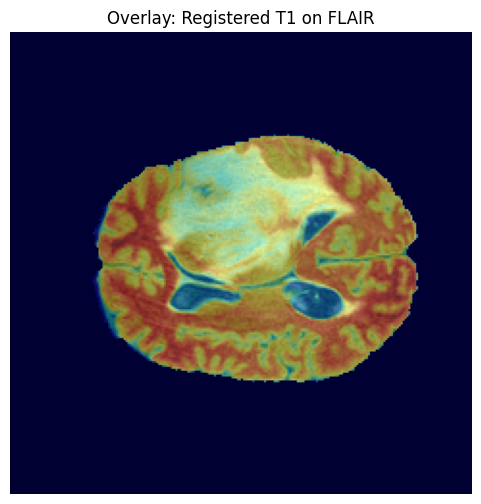

In [20]:
slice_index = 80

plt.figure(figsize=(6,6))
plt.imshow(fixed_np[:,:,slice_index], cmap="gray")
plt.imshow(warped_np[:,:,slice_index], cmap="jet", alpha=0.4)
plt.title("Overlay: Registered T1 on FLAIR")
plt.axis("off")

(np.float64(-0.5), np.float64(239.5), np.float64(239.5), np.float64(-0.5))

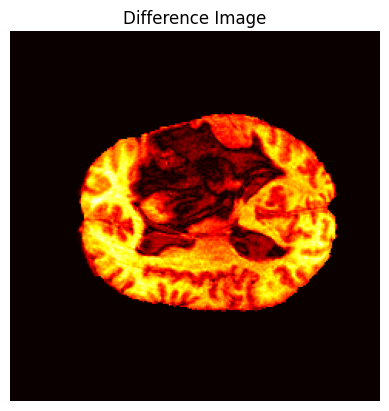

In [23]:
diff = abs(fixed_np[:, :, slice_index] - warped_np[:, :, slice_index])

plt.imshow(diff, cmap="hot")
plt.title("Difference Image")
plt.axis("off")

Text(0.5, 1.0, 'Registered Moving')

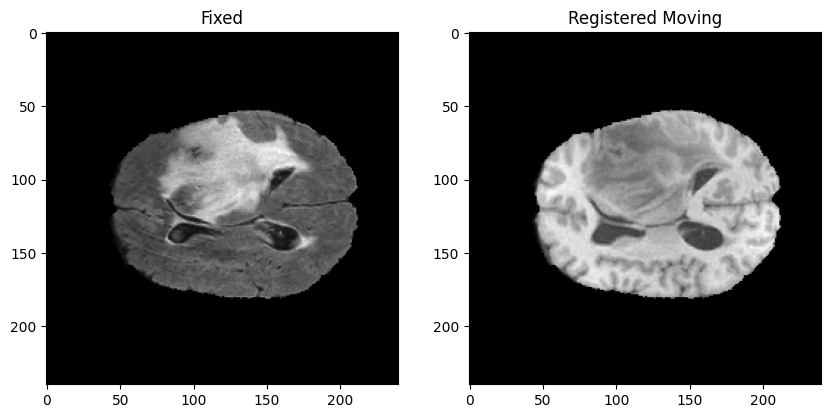

In [25]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(fixed_np[:, :, slice_index], cmap="gray")
plt.title("Fixed")

plt.subplot(1, 2, 2)
plt.imshow(warped_np[:, :, slice_index], cmap="gray")
plt.title("Registered Moving")

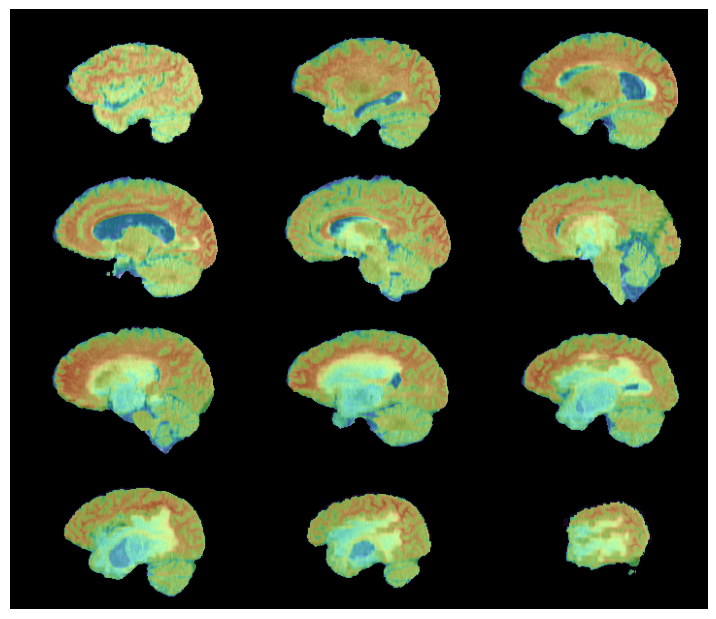

In [26]:
ants.plot(
    fixed,
    warped,
    overlay_alpha=0.5
)

In [27]:
mi = ants.image_mutual_information(fixed, warped)
print(mi) # higher Mutual Information usually indicates better alignment

-0.45328530143676443


Similarity Metrics: Mutual Information, Cross-Correlation, MSE (Mean Squared Error), and Dice Score

Transformations: Rigid, Affine, Homography, Local Deformations
^ more include: Deformable, Resampling & Isotropic Voxel Transformation, Fourier Reconstruction

Linear/Affine Transforms

These transformations maintain straight lines and parallel lines throughout the image. 
- Translation: Only allows shifting the image in x, y, or z directions.
- Rigid: Only allows translation and rotation (6 degrees of freedom in 3D). It does not deform or scale the object, making it useful for aligning images from the same subject.
- QuickRigid: A faster, simplified version of the rigid transformation.
- DenseRigid: A rigid transformation that employs denser sampling for better metric estimation.
- BOLDRigid: Rigid transformation optimized for BOLD to BOLD intrasubject registration.
- Similarity: Allows uniform scaling (resizing), rotation, and translation.
- Affine: Allows translation, rotation, scaling, and shearing (12 degrees of freedom in 3D). It is typically used for registering subjects with different overall brain sizes.
- AffineFast: A faster version of the standard Affine transformation.
- BOLDAffine: Affine transformation tailored for BOLD to T1 registration. 


Non-Linear/Deformable Transforms

These transformations allow for local deformations to match fine-scale anatomical structures like gyri and sulci. 
- SyN (Symmetric Normalization): The standard, high-performance diffeomorphic registration algorithm that is symmetric, meaning the mapping from A to B is the same as the inverse of B to A.
- SyNRA: A multistage approach: Rigid + Affine + SyN.
- SyNOnly: Only the deformable SyN stage, assuming the images are already aligned linearly.
- Elastic: Affine + elastic deformation (a simplified, less flexible non-linear model).
- ElasticSyN: Symmetric normalization with elastic regularization.
- SyNCC/SyNMeanSquares/SyNDemons: SyN utilizing specific metric types (Cross-Correlation, Mean Squares, or Demons).
- SyNAggro / SyNLessAggro: "Aggressive" SyN, optimized for finer-scale, more intense deformation.
- TV[]/ TVMSQ / TVMSQC: Time-varying diffeomorphisms with different metrics.


In [ ]:
Specialized/Composite Transforms

- TRSAA: Performs translation, rigid, similarity, and affine transformations twice for high-quality linear alignment.
- antsRegistrationSyN[x]: A suite of wrapper scripts that recreate the antsRegistrationSyN.sh functionality, where x can be:
    - t: Translation
    - r: Rigid
    - a: Rigid + Affine
    - s: Rigid + Affine + SyN
    - sr: Rigid + SyN
    - so: SyN Only
    - b: Rigid + Affine + B-spline SyN
    - br: Rigid + B-spline SyN
    - bo: B-spline SyN only.
- antsRegistrationSyNQuick[x]: A faster version of the antsRegistrationSyN suite using lower iteration counts.


Transform Output Formats 

ANTs usually saves transformations as: 
- 0GenericAffine.mat: Linear transformation components (ASCII or HDF5).
- 1Warp.nii.gz & 1InverseWarp.nii.gz: Deformation fields (displacement vectors)

In [ ]:
reg = ants.registration(
    fixed = fixed,
    moving = moving,
    type_of_transform="SyN" # deformable warp
)

In [29]:
import numpy as np

(np.float64(-0.5), np.float64(239.5), np.float64(239.5), np.float64(-0.5))

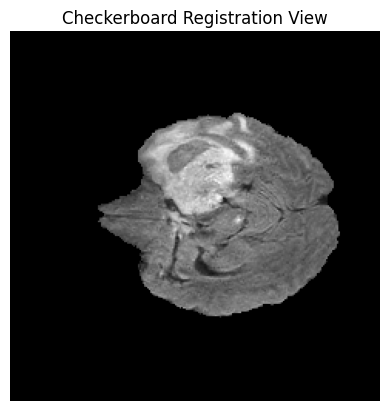

In [32]:
slice_idx = 55

fixed_slice = fixed.numpy()[:, :, slice_idx]
warped_slice = warped.numpy()[:, :, slice_idx]

h, w = fixed_slice.shape
checkerboard = np.zeros((h, w))

tile = 20

'''
If registration is good, the boundaries between squares will line up smoothly.
brain edges align smoothly across tiles
ventricles continue across tile boundaries

If registration is bad, you’ll see discontinuities at the square edges.
edges jump at tile borders
structures don't line up
'''

for i in range(h): # checkerboard trick
    for j in range(w):
        if ((i // tile) + (j // tile)) % 2 == 0:
            checkerboard[i, j] = fixed_slice[i, j]
        else:
            checkerboard[i, j] = fixed_slice[i, j]

plt.imshow(checkerboard, cmap="gray")
plt.title("Checkerboard Registration View")
plt.axis("off")


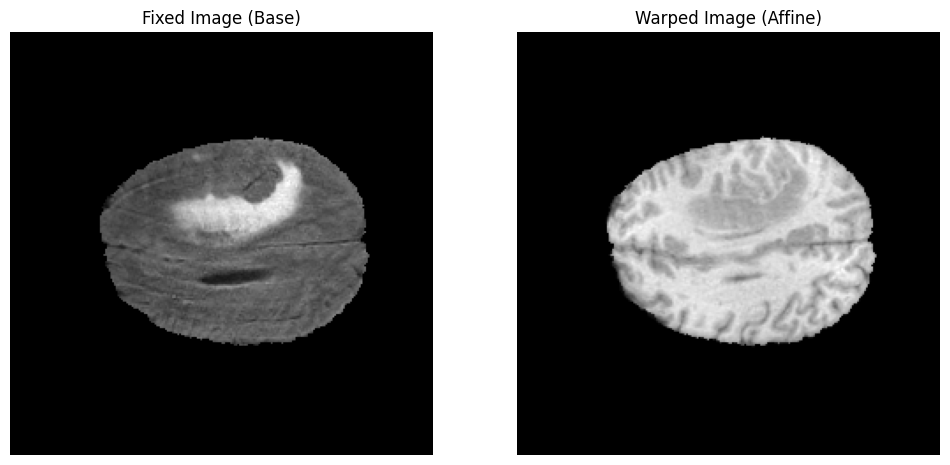

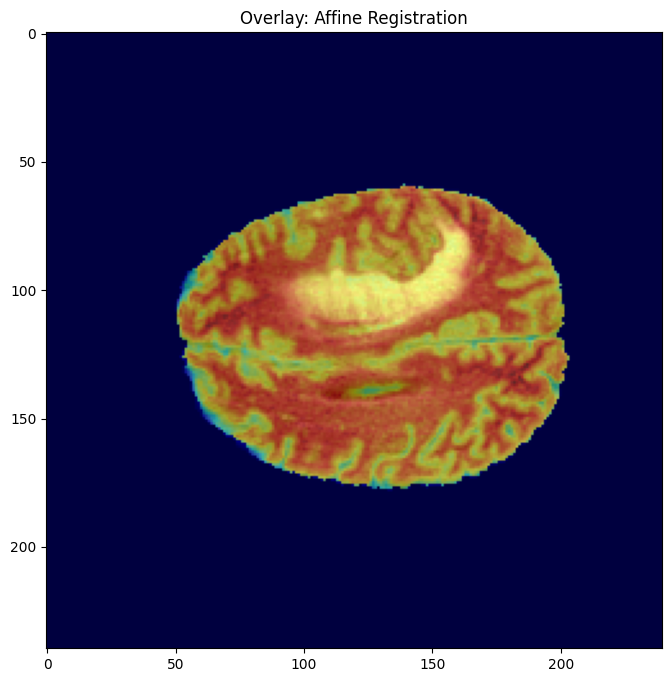

In [35]:
# Rigid vs Affine vs Deformable Transformations
type_of_transform1="Rigid" # aligns orientation
type_of_transform2="Affine" # fixes scale/shear
type_of_transform3="SyN" # corrects anatomical deformation


# 1. Align centers of mass first so the Affine transform starts in the right spot
reg = ants.registration(
    fixed = fixed,
    moving = moving,
    type_of_transform = 'Translation', # Quick alignment of centers
)


# 2. Use that translation as the starting point for Affine/SyN
reg = ants.registration(
    fixed = fixed,
    moving = moving,
    type_of_transform = type_of_transform2
)

warped = reg["warpedmovout"] 

# convert to numpy to visualize
fixed_np = fixed.numpy()
warped_np = warped.numpy()

# 1. Normalize intensities for better overlay visibility
def normalize(data):
    return (data - np.min(data)) / (np.max(data) - np.min(data) + 1e-8)

fixed_norm = normalize(fixed_np[:, :, slice_index])
warped_norm = normalize(warped_np[:, :, slice_index])


slice_index = 100

plt.figure(figsize=(12,6))

# Side-by-side to verify both exist
plt.subplot(1, 2, 1)
plt.imshow(fixed_norm, cmap="gray")
plt.title("Fixed Image (Base)")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(warped_norm, cmap="gray")
plt.title(f"Warped Image ({type_of_transform2})")
plt.axis("off")


# The Overlay
plt.figure(figsize=(8, 8))
plt.imshow(fixed_norm, cmap="gray")
# Use a bright colormap like 'magma' or 'jet' for the moving image
plt.imshow(warped_norm, cmap="jet", alpha=0.5) 
plt.title(f"Overlay: {type_of_transform2} Registration")
plt.show()


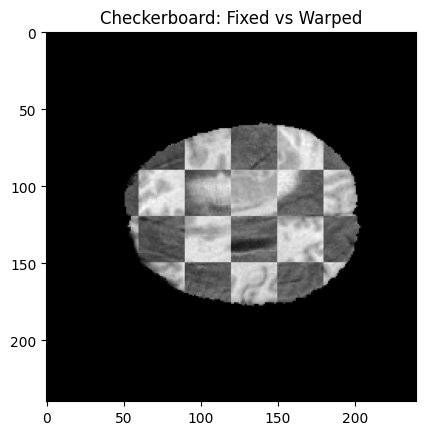

In [36]:
def checkerboard(im1, im2, n=8):
    h, w = im1.shape
    check = np.zeros((h, w))
    dy, dx = h // n, w // n
    for i in range(n):
        for j in range(n):
            if (i + j) % 2 == 0:
                check[i*dy:(i+1)*dy, j*dx:(j+1)*dx] = im1[i*dy:(i+1)*dy, j*dx:(j+1)*dx]
            else:
                check[i*dy:(i+1)*dy, j*dx:(j+1)*dx] = im2[i*dy:(i+1)*dy, j*dx:(j+1)*dx]
    return check

# Use it on your slice
check_view = checkerboard(fixed_norm, warped_norm)
plt.imshow(check_view, cmap="gray")
plt.title("Checkerboard: Fixed vs Warped")
plt.show()

In [37]:
# Break Registration on Purpose

# shift the image artificially
shifted = np.roll(moving.numpy(), 20, axis=0)

# convert back to ANTs
shifted_img = ants.from_numpy(shifted)

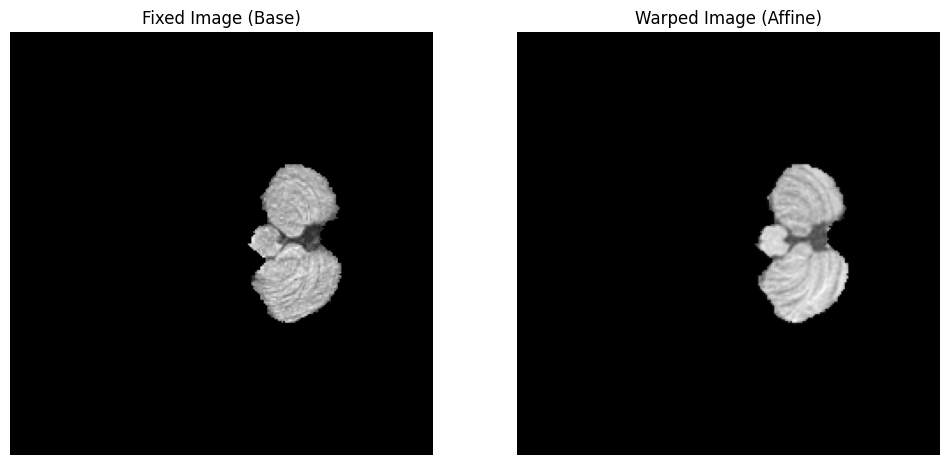

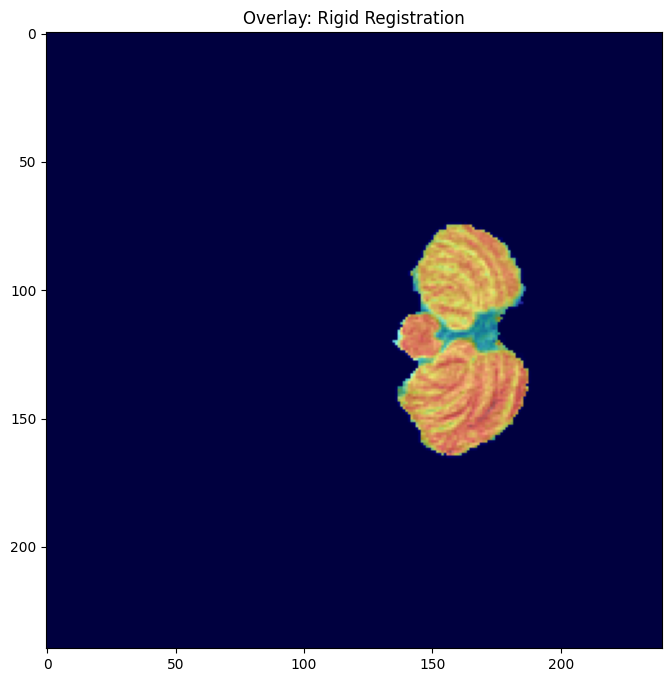

In [39]:
reg = ants.registration(
    fixed = fixed,
    moving = moving,
    type_of_transform = type_of_transform1
)

warped = reg["warpedmovout"] 

# convert to numpy to visualize
fixed_np = fixed.numpy()
warped_np = warped.numpy()

fixed_norm = normalize(fixed_np[:, :, slice_index])
warped_norm = normalize(warped_np[:, :, slice_index])


slice_index = 20

plt.figure(figsize=(12,6))

# Side-by-side to verify both exist
plt.subplot(1, 2, 1)
plt.imshow(fixed_norm, cmap="gray")
plt.title("Fixed Image (Base)")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(warped_norm, cmap="gray")
plt.title(f"Warped Image ({type_of_transform2})")
plt.axis("off")


# The Overlay
plt.figure(figsize=(8, 8))
plt.imshow(fixed_norm, cmap="gray")
# Use a bright colormap like 'magma' or 'jet' for the moving image
plt.imshow(warped_norm, cmap="jet", alpha=0.5) 
plt.title(f"Overlay: {type_of_transform1} Registration")
plt.show()

More Experiments to try:
- Registration Failure, 2 completely different patients
- Multi-modal Registration
- Preprocessing Effects


'\nShould see alignment in:\nskull boundary\nventricles\ncortex folds\ntumor boundaries\n\nMisalignment often appears at:\nbrain edges\nventricles\ntumor regions\n\n'

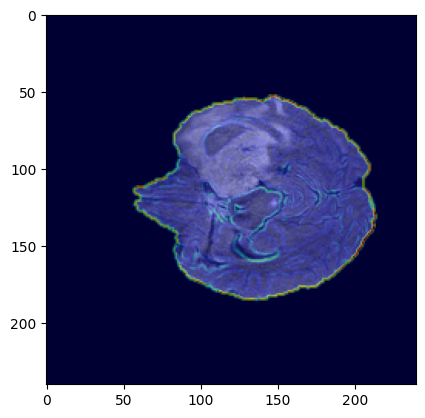

In [41]:
from skimage.filters import sobel

edges = sobel(warped_slice) # highlights misaligned boundaries

plt.imshow(fixed_slice, cmap="gray")
plt.imshow(edges, cmap="jet", alpha=0.4)

'''
Should see alignment in:
skull boundary
ventricles
cortex folds
tumor boundaries

Misalignment often appears at:
brain edges
ventricles
tumor regions

'''